In [1]:
import os

os.chdir(r"C:\Users\Sneha G\Downloads\DataAnalytics-L2-Task4-AndroidAppMarket")

print(os.getcwd())

C:\Users\Sneha G\Downloads\DataAnalytics-L2-Task4-AndroidAppMarket


In [2]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'googleplaystore.csv', 'googleplaystore_user_reviews.csv', 'OIBSIP_DataAnalytics_L2_Task4_Android_App_Market.ipynb', 'README.md.txt']


In [3]:
import pandas as pd

apps = pd.read_csv("googleplaystore.csv")

apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
reviews = pd.read_csv("googleplaystore_user_reviews.csv")

reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [5]:
apps.shape

(10841, 13)

In [6]:
apps.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [7]:
apps.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [8]:
apps.duplicated().sum()

483

In [9]:
apps = apps.drop_duplicates()

print("Duplicate rows removed.")
print("New shape:", apps.shape)

Duplicate rows removed.
New shape: (10358, 13)


In [10]:
apps.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [11]:
apps[["Category", "Rating", "Reviews", "Size", "Installs", "Type", "Price"]].head()

,Category,Rating,Reviews,Size,Installs,Type,Price
0,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0
1,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0
2,ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0
3,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0
4,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0


In [12]:
apps["Rating"] = apps["Rating"].fillna(apps["Rating"].median())

print("Missing ratings after cleaning:", apps["Rating"].isnull().sum())

Missing ratings after cleaning: 0


In [13]:
apps["Installs"] = (
    apps["Installs"]
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(int)
)

print(apps["Installs"].head())

ValueError: invalid literal for int() with base 10: 'Free'

In [14]:
apps[apps["Installs"].isin(["Free", "Paid"])]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [15]:
apps = apps[apps["Category"] != "1.9"]

print("Incorrect row removed.")
print("New shape:", apps.shape)

Incorrect row removed.
New shape: (10357, 13)


In [16]:
apps["Installs"] = (
    apps["Installs"]
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(int)
)

print("Installs cleaned successfully.")
print(apps["Installs"].head())

Installs cleaned successfully.
0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int32


In [17]:
apps["Price"] = (
    apps["Price"]
    .str.replace("$", "", regex=False)
    .astype(float)
)

print("Price cleaned successfully.")
print(apps["Price"].head())

Price cleaned successfully.
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64


In [18]:
apps[["Installs", "Price"]].head()

,Installs,Price
0,10000,0.0
1,500000,0.0
2,5000000,0.0
3,50000000,0.0
4,100000,0.0


In [19]:
category_counts = apps["Category"].value_counts()

plt.figure(figsize=(12, 6))
category_counts.plot(kind="bar")

plt.title("Number of Apps by Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [20]:
import matplotlib.pyplot as plt

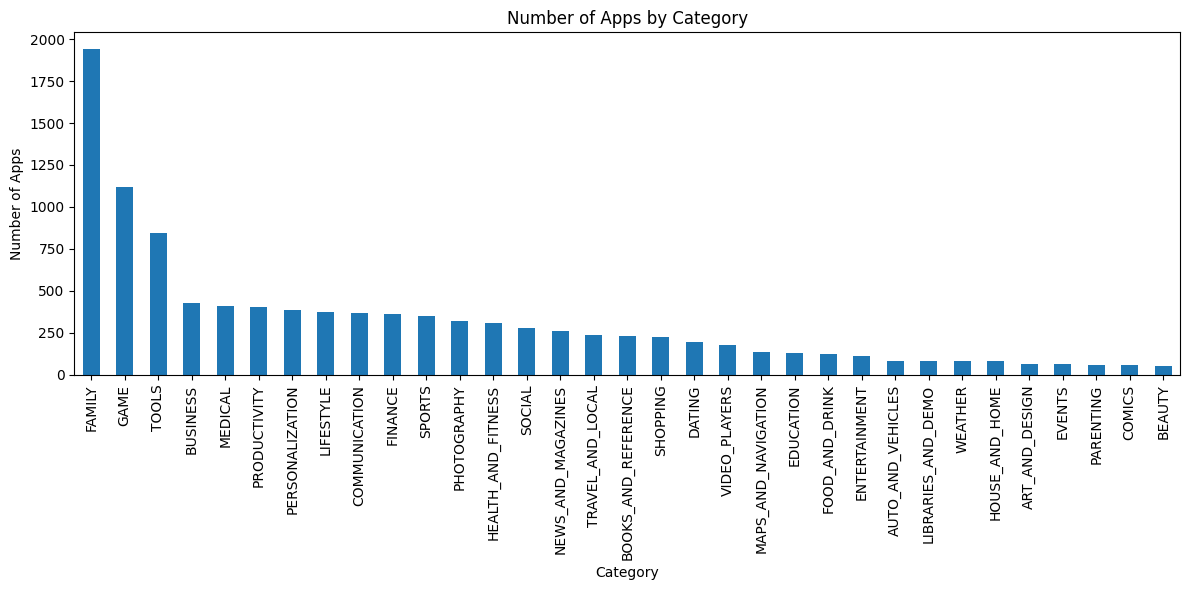

In [21]:
category_counts = apps["Category"].value_counts()

plt.figure(figsize=(12, 6))
category_counts.plot(kind="bar")

plt.title("Number of Apps by Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

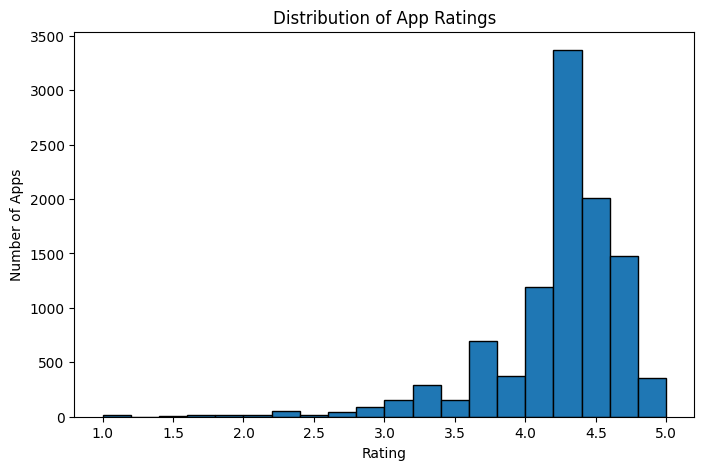

In [22]:
plt.figure(figsize=(8, 5))

apps["Rating"].plot(
    kind="hist",
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.show()

In [23]:
avg_rating_category = apps.groupby("Category")["Rating"].mean().sort_values(ascending=False)

print(avg_rating_category)

Category
EVENTS                 4.395313
EDUCATION              4.375385
ART_AND_DESIGN         4.355385
BOOKS_AND_REFERENCE    4.336522
PERSONALIZATION        4.327062
PARENTING              4.300000
BEAUTY                 4.283019
GAME                   4.282070
HEALTH_AND_FITNESS     4.266993
SOCIAL                 4.260714
SHOPPING               4.256250
WEATHER                4.248780
SPORTS                 4.239031
PRODUCTIVITY           4.219410
MEDICAL                4.212990
LIBRARIES_AND_DEMO     4.207059
AUTO_AND_VEHICLES      4.205882
FAMILY                 4.203757
PHOTOGRAPHY            4.189441
HOUSE_AND_HOME         4.185000
FOOD_AND_DRINK         4.183871
COMMUNICATION          4.175410
BUSINESS               4.175176
NEWS_AND_MAGAZINES     4.160985
COMICS                 4.160000
FINANCE                4.148056
ENTERTAINMENT          4.136036
LIFESTYLE              4.133244
TRAVEL_AND_LOCAL       4.121941
VIDEO_PLAYERS          4.084000
TOOLS                  4.080071

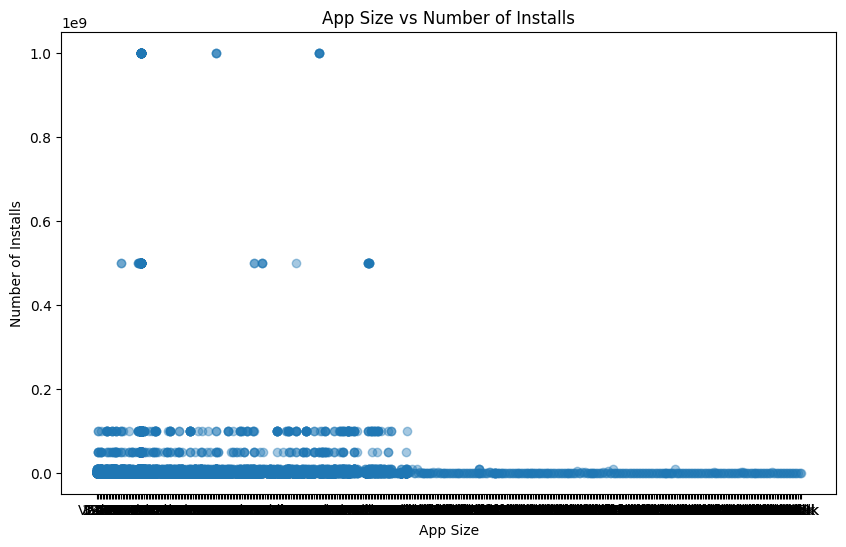

In [24]:
plt.figure(figsize=(10, 6))

plt.scatter(
    apps["Size"],
    apps["Installs"],
    alpha=0.4
)

plt.title("App Size vs Number of Installs")
plt.xlabel("App Size")
plt.ylabel("Number of Installs")
plt.show()

Free    9591
Paid     765
Name: Type, dtype: int64


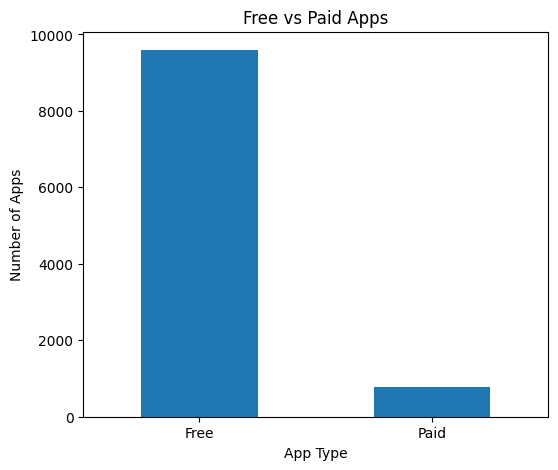

In [25]:
type_counts = apps["Type"].value_counts()

print(type_counts)

plt.figure(figsize=(6, 5))
type_counts.plot(kind="bar")

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")
plt.xticks(rotation=0)
plt.show()

In [26]:
paid_apps = apps[apps["Type"] == "Paid"]

print("Number of paid apps:", len(paid_apps))
print("Average price of paid apps: $", round(paid_apps["Price"].mean(), 2))

Number of paid apps: 765
Average price of paid apps: $ 13.96


In [27]:
paid_apps["Estimated_Revenue"] = paid_apps["Price"] * paid_apps["Installs"]

paid_apps[["App", "Price", "Installs", "Estimated_Revenue"]].head()

c:\users\sneha g\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


,App,Price,Installs,Estimated_Revenue
234,TurboScan: scan documents and receipts in PDF,4.99,100000,499000.0
235,Tiny Scanner Pro: PDF Doc Scan,4.99,100000,499000.0
427,Puffin Browser Pro,3.99,100000,399000.0
476,"Moco+ - Chat, Meet People",3.99,10000,39900.0
477,Calculator,6.99,1000,6990.0


In [28]:
reviews.shape

(64295, 5)

In [29]:
reviews.columns

Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')

In [30]:
reviews["Translated_Review"].isnull().sum()

26868

In [31]:
reviews = reviews.dropna(subset=["Translated_Review"])

print("Reviews after removing missing text:", reviews.shape)

Reviews after removing missing text: (37427, 5)


In [32]:
!pip install textblob

     -------------------------------------- 42.0/42.0 kB 337.6 kB/s eta 0:00:00
     ---------------------------------------- 58.7/58.7 kB 1.0 MB/s eta 0:00:00
   ---------------------------------------- 636.8/636.8 kB 5.7 MB/s eta 0:00:00
   ---------------------------------------- 1.5/1.5 MB 8.7 MB/s eta 0:00:00
   ---------------------------------------- 269.6/269.6 kB 8.4 MB/s eta 0:00:00
   ---------------------------------------- 78.6/78.6 kB 2.2 MB/s eta 0:00:00


In [33]:
from textblob import TextBlob

print("TextBlob imported successfully!")

TextBlob imported successfully!


In [34]:
reviews["Polarity"] = reviews["Translated_Review"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

reviews[["Translated_Review", "Polarity"]].head()

,Translated_Review,Polarity
0,I like eat delicious food. That's I'm cooking ...,1.00
1,This help eating healthy exercise regular basis,0.25
3,Works great especially going grocery store,0.40
4,Best idea us,1.00
5,Best way,1.00


In [35]:
def get_sentiment(polarity):
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

reviews["Sentiment"] = reviews["Polarity"].apply(get_sentiment)

print(reviews["Sentiment"].value_counts())

Positive    23998
Negative     8271
Neutral      5158
Name: Sentiment, dtype: int64


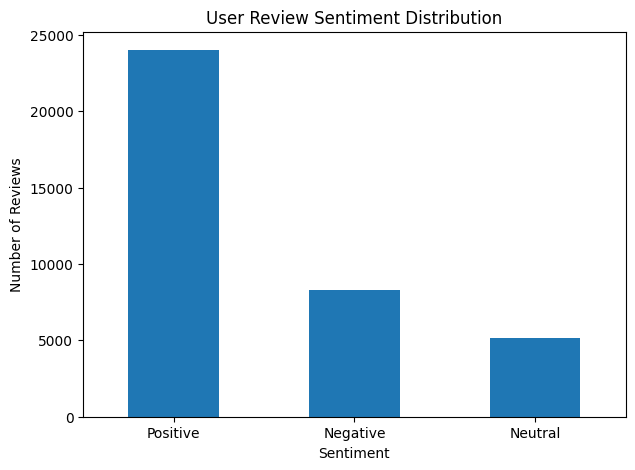

In [36]:
sentiment_counts = reviews["Sentiment"].value_counts()

plt.figure(figsize=(7, 5))
sentiment_counts.plot(kind="bar")

plt.title("User Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

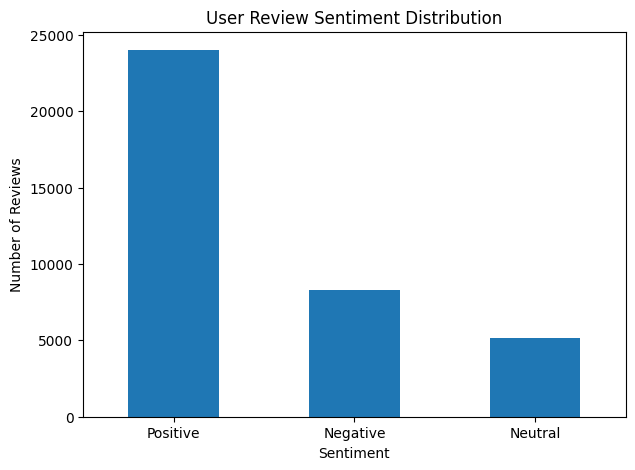

In [37]:
sentiment_counts = reviews["Sentiment"].value_counts()

plt.figure(figsize=(7, 5))
sentiment_counts.plot(kind="bar")

plt.title("User Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [38]:
app_category = apps[["App", "Category"]].drop_duplicates()

reviews_with_category = reviews.merge(
    app_category,
    on="App",
    how="left"
)

reviews_with_category[["App", "Category", "Sentiment"]].head()

,App,Category,Sentiment
0,10 Best Foods for You,HEALTH_AND_FITNESS,Positive
1,10 Best Foods for You,HEALTH_AND_FITNESS,Positive
2,10 Best Foods for You,HEALTH_AND_FITNESS,Positive
3,10 Best Foods for You,HEALTH_AND_FITNESS,Positive
4,10 Best Foods for You,HEALTH_AND_FITNESS,Positive


In [39]:
sentiment_by_category = pd.crosstab(
    reviews_with_category["Category"],
    reviews_with_category["Sentiment"]
)

print(sentiment_by_category)

Sentiment            Negative  Neutral  Positive
Category                                        
ART_AND_DESIGN             61       62       259
AUTO_AND_VEHICLES          17       36       236
BEAUTY                     65       88       185
BOOKS_AND_REFERENCE        95      108       448
BUSINESS                  169      258       655
COMICS                      1        5        39
COMMUNICATION             209      176       642
DATING                    361      286      1068
EDUCATION                 102       90       655
ENTERTAINMENT             319      185       760
EVENTS                     16       17       125
FAMILY                   1236      372      2741
FINANCE                   320      204       911
FOOD_AND_DRINK             92       84       462
GAME                     2408      334      3936
HEALTH_AND_FITNESS        257      238      1754
HOUSE_AND_HOME             87      109       315
LIBRARIES_AND_DEMO         51       44       238
LIFESTYLE           

In [40]:
sentiment_percentage = sentiment_by_category.div(
    sentiment_by_category.sum(axis=1),
    axis=0
) * 100

sentiment_percentage.round(2)

Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,15.97,16.23,67.80
AUTO_AND_VEHICLES,5.88,12.46,81.66
BEAUTY,19.23,26.04,54.73
BOOKS_AND_REFERENCE,14.59,16.59,68.82
BUSINESS,15.62,23.84,60.54
COMICS,2.22,11.11,86.67
COMMUNICATION,20.35,17.14,62.51
DATING,21.05,16.68,62.27
EDUCATION,12.04,10.63,77.33


In [41]:
positive_by_category = (
    reviews_with_category[reviews_with_category["Sentiment"] == "Positive"]
    .groupby("Category")
    .size()
    .sort_values(ascending=False)
)

print(positive_by_category.head(10))

Category
GAME                  3936
FAMILY                2741
HEALTH_AND_FITNESS    1754
DATING                1068
SPORTS                1044
TRAVEL_AND_LOCAL      1034
PRODUCTIVITY           990
MEDICAL                967
FINANCE                911
TOOLS                  876
dtype: int64


In [42]:
insights = {
    "Total Apps": len(apps),
    "Total Reviews Analyzed": len(reviews),
    "Average Rating": round(apps["Rating"].mean(), 2),
    "Free Apps": int((apps["Type"] == "Free").sum()),
    "Paid Apps": int((apps["Type"] == "Paid").sum()),
    "Positive Reviews": int((reviews["Sentiment"] == "Positive").sum()),
    "Negative Reviews": int((reviews["Sentiment"] == "Negative").sum()),
    "Neutral Reviews": int((reviews["Sentiment"] == "Neutral").sum())
}

pd.Series(insights)

Total Apps                10357.0
Total Reviews Analyzed    37427.0
Average Rating                4.2
Free Apps                  9591.0
Paid Apps                   765.0
Positive Reviews          23998.0
Negative Reviews           8271.0
Neutral Reviews            5158.0
dtype: float64

## Conclusion

The Google Play Store dataset was analyzed to understand app categories, ratings, installs, size, pricing, and user sentiment.

The analysis included data cleaning, category distribution, rating analysis, size versus installs, free versus paid apps, estimated revenue for paid apps, and sentiment analysis of user reviews using TextBlob.

The results provide insights into app popularity, user satisfaction, pricing patterns, and differences in sentiment across app categories.